In [23]:
import ccxt
import matplotlib.pyplot as plt
print(ccxt.exchanges)

exchange = ccxt.hyperliquid()

['alp', 'alpaca', 'apex', 'arkham', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bydfi', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincatch', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'defx', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'fmfwio', 'foxbit', 'gate', 'gateio', 'gemini', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax', 'o

In [ ]:
import pandas as pd
import time
from datetime import datetime, timedelta

def to_dataframe(candles: list[list[float]]) -> pd.DataFrame:
    df = pd.DataFrame(candles, columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
    df['datetime'] = pd.to_datetime(df['datetime'], unit='ms')
    df = df.set_index('datetime').sort_index()
    
    return df

def fetch_ohlcv_range(symbol: str, timeframe: str, start_ts_ms: int, end_ts_ms: int) -> pd.DataFrame:
    all_candles: list[list[float]] = []
    current_since = start_ts_ms
    limit = 100

    while current_since < end_ts_ms:
        candles = exchange.fetch_ohlcv(
            symbol=symbol,
            timeframe=timeframe,
            since=current_since,
            limit=limit
        )
        if not candles:
            break

        all_candles.extend(candles)

        last_ts = candles[-1][0]
        if last_ts >= end_ts_ms:
            break

        current_since = last_ts + 1

        time.sleep(1)

    return to_dataframe(all_candles)


since = int((datetime.now() - timedelta(days=7)).timestamp() * 1000)
end = int(datetime.now().timestamp() * 1000)
symbol = 'BTC/USDC:USDC'
timeframe = '1m'

df = fetch_ohlcv_range(
    symbol=symbol,
    timeframe=timeframe,
    start_ts_ms=since,
    end_ts_ms=end
)
print(df.head())
df.to_csv(f'{symbol.replace('/', '_')}_hyperliquid_{timeframe}_{since}_{end}.csv')

In [27]:
df_bitget = pd.read_csv("BTC_USDT:USDT_bitget_1m_1771142134953_1771746934953.csv", index_col='datetime')
print(df_bitget.head())

df_hyperliquid = pd.read_csv("BTC_USDC:USDC_hyperliquid_1m_1771142529518_1771747329518.csv", index_col='datetime')
print(df_hyperliquid.head())

df_merged = pd.merge(df_bitget, df_hyperliquid, how='inner', on='datetime', suffixes=("_bitget", "_hyperliquid"))[["close_bitget", "close_hyperliquid"]]
print(df_merged)
df_merged.to_csv("ccxt_data_btc_different_exchanges.csv")

df_merged['spread'] = df_merged['close_bitget'] - df_merged['close_hyperliquid']
print(df_merged)

                        open     high      low    close   volume
datetime                                                        
2026-02-15 07:56:00  70698.6  70720.0  70667.8  70708.5   5.0154
2026-02-15 07:57:00  70708.5  70720.0  70663.5  70671.8  10.9627
2026-02-15 07:58:00  70671.8  70736.3  70671.8  70735.3  10.8820
2026-02-15 07:59:00  70735.3  70777.0  70722.0  70776.9  39.2537
2026-02-15 08:00:00  70776.9  70800.0  70763.8  70774.0  33.9438
                        open     high      low    close    volume
datetime                                                         
2026-02-18 17:32:00  67158.0  67161.0  67104.0  67126.0   3.65398
2026-02-18 17:33:00  67123.0  67123.0  67095.0  67106.0   4.77823
2026-02-18 17:34:00  67106.0  67119.0  67063.0  67119.0  52.14513
2026-02-18 17:35:00  67122.0  67162.0  67120.0  67160.0   4.69645
2026-02-18 17:36:00  67161.0  67170.0  67141.0  67149.0   3.28116
                     close_bitget  close_hyperliquid
datetime                      

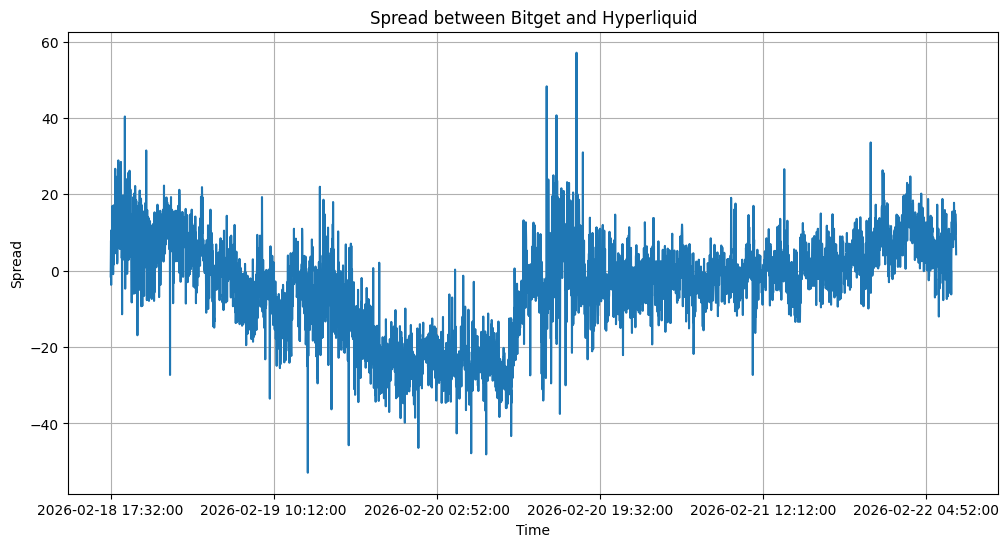

In [25]:
plt.figure(figsize=(12, 6))
df_merged['spread'].plot()
plt.title('Spread between Bitget and Hyperliquid')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.grid(True)
plt.show()